# Lab 9: SIFT Implementation

### Importing Libraries

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec

### Configuration

In [10]:
TOP_N        = 10                   # number of best matches to display
RATIO_THRESH = 0.75                 # Lowe's ratio test threshold
IMAGE_PATH = "house.jpg"

### Helper Functions

In [11]:
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Could not load image at: {path}")
    return img


def to_rgb(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def to_gray(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

### Transformations

In [12]:
def rotate(img, angle):
    """Rotate image about its centre by `angle` degrees (keeps full canvas)."""
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    # Expand canvas so corners are not clipped
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)
    M[0, 2] += new_w / 2 - cx
    M[1, 2] += new_h / 2 - cy
    return cv2.warpAffine(img, M, (new_w, new_h),
                          flags=cv2.INTER_LINEAR,
                          borderMode=cv2.BORDER_REFLECT)


def scale(img, fx, fy):
    """Scale image by factors fx (width) and fy (height)."""
    return cv2.resize(img, None, fx=fx, fy=fy,
                      interpolation=cv2.INTER_LINEAR)


def add_gaussian_noise(img, mean=0, std=25):
    """Add Gaussian noise to a BGR image."""
    noise = np.random.normal(mean, std, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    return noisy


def adjust_brightness(img, beta):
    """Shift pixel values by beta (+bright / -dark)."""
    return np.clip(img.astype(np.int32) + beta, 0, 255).astype(np.uint8)


def blur(img, ksize=15):
    """Apply Gaussian blur with kernel size ksize x ksize."""
    return cv2.GaussianBlur(img, (ksize, ksize), 0)


def flip_horizontal(img):
    return cv2.flip(img, 1)


def perspective_warp(img, strength=0.15):
    """Apply a mild perspective (projective) warp."""
    h, w = img.shape[:2]
    s = strength
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst = np.float32([
        [w * s,       h * s * 0.5],
        [w * (1 - s * 0.5), h * s],
        [w * (1 - s), h * (1 - s * 0.5)],
        [w * s * 0.5, h * (1 - s)]
    ])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(img, M, (w, h),
                               borderMode=cv2.BORDER_REFLECT)

### SIFT Matching

In [13]:
def sift_match(img_base_bgr, img_query_bgr, top_n=10, ratio=0.75):
    """
    Detect SIFT keypoints, match descriptors with Lowe's ratio test,
    return sorted top_n good matches plus the keypoint lists.
    """
    sift = cv2.SIFT_create()
    g1   = to_gray(img_base_bgr)
    g2   = to_gray(img_query_bgr)

    kp1, des1 = sift.detectAndCompute(g1, None)
    kp2, des2 = sift.detectAndCompute(g2, None)

    if des1 is None or des2 is None or len(des1) < 2 or len(des2) < 2:
        return [], kp1, kp2

    bf      = cv2.BFMatcher(cv2.NORM_L2)
    matches = bf.knnMatch(des1, des2, k=2)

    good = [m for m, n in matches if m.distance / n.distance < ratio]
    good = sorted(good, key=lambda x: x.distance)[:top_n]
    return good, kp1, kp2

### Colored Match Visualization

In [14]:
def draw_colored_matches(img1_bgr, kp1, img2_bgr, kp2, matches):
    """
    Draw matched keypoints with one unique colour per match pair.
    Returns an RGB numpy array suitable for imshow.
    """
    rgb1 = to_rgb(img1_bgr)
    rgb2 = to_rgb(img2_bgr)

    h1, w1 = rgb1.shape[:2]
    h2, w2 = rgb2.shape[:2]
    h_out  = max(h1, h2)
    canvas = np.zeros((h_out, w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1]      = rgb1
    canvas[:h2, w1:w1+w2] = rgb2

    n = max(len(matches), 1)
    colors = [tuple((np.array(cm.tab10(i % 10)[:3]) * 255).astype(int).tolist())
              for i in range(n)]

    for idx, m in enumerate(matches):
        x1, y1 = map(int, kp1[m.queryIdx].pt)
        x2, y2 = map(int, kp2[m.trainIdx].pt)
        x2_off  = x2 + w1
        c = colors[idx]
        cv2.circle(canvas, (x1,     y1), 7, c, -1)
        cv2.circle(canvas, (x2_off, y2), 7, c, -1)
        cv2.line(canvas,   (x1,     y1), (x2_off, y2), c, 1, cv2.LINE_AA)

    return canvas

### Main

In [15]:
def run_pipeline(image_path=IMAGE_PATH, top_n=TOP_N, ratio=RATIO_THRESH):

    # ── 1. Load original ──────────────────────────────────────────────────────
    original = load_image(image_path)
    print(f"[INFO] Loaded image: {image_path}  shape={original.shape}")

    # ── 2. Build transformed variants ─────────────────────────────────────────
    transforms = {
        "Rotation 30°":          rotate(original, 30),
        "Rotation 60°":          rotate(original, 60),
        "Scale 0.6×":            scale(original, 0.6, 0.6),
        "Scale 1.4×":            scale(original, 1.4, 1.4),
        "Gaussian Noise":        add_gaussian_noise(original, std=30),
        "Brightness +80":        adjust_brightness(original, 80),
        "Gaussian Blur":         blur(original, ksize=15),
        "Horizontal Flip":       flip_horizontal(original),
        "Perspective Warp":      perspective_warp(original, strength=0.15),
    }

    print(f"[INFO] Created {len(transforms)} transformed variants.")

    # ── 3. Run SIFT on each (original → transformed) pair ────────────────────
    results = {}
    for name, transformed in transforms.items():
        matches, kp1, kp2 = sift_match(original, transformed,
                                        top_n=top_n, ratio=ratio)
        results[name] = {
            "transformed": transformed,
            "matches":     matches,
            "kp1":         kp1,
            "kp2":         kp2,
        }
        print(f"  [{name:25s}]  keypoints: {len(kp1):4d} → {len(kp2):4d}"
              f"   good matches: {len(matches)}")

    # ── 4. Visualise: transformed images grid ─────────────────────────────────
    n_cols = 3
    n_rows = (len(transforms) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()
    for ax in axes:
        ax.axis("off")

    for idx, (name, data) in enumerate(results.items()):
        axes[idx].imshow(to_rgb(data["transformed"]))
        axes[idx].set_title(name, fontsize=11, fontweight="bold", pad=6)
        axes[idx].axis("off")

    fig.suptitle("Transformed Variants of Original Image",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("transformed_variants.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[SAVED] transformed_variants.png")

    # ── 5. Visualise: SIFT match results grid ─────────────────────────────────
    fig2, axes2 = plt.subplots(n_rows, n_cols,
                               figsize=(10 * n_cols, 5 * n_rows))
    axes2 = axes2.flatten()
    for ax in axes2:
        ax.axis("off")

    for idx, (name, data) in enumerate(results.items()):
        canvas = draw_colored_matches(
            original,         data["kp1"],
            data["transformed"], data["kp2"],
            data["matches"]
        )
        axes2[idx].imshow(canvas)
        axes2[idx].set_title(
            f"{name}  |  {len(data['matches'])} matches",
            fontsize=10, fontweight="bold", pad=6
        )
        axes2[idx].axis("off")

    fig2.suptitle(f"SIFT — Top {top_n} Matches: Original vs Each Transform",
                  fontsize=16, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("sift_all_matches.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[SAVED] sift_all_matches.png")

    # ── 6. Visualise: Keypoint density on original ───────────────────────────
    sift    = cv2.SIFT_create()
    kp_orig = sift.detect(to_gray(original), None)
    kp_img  = cv2.drawKeypoints(
        original, kp_orig, None,
        flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    plt.figure(figsize=(8, 6))
    plt.imshow(to_rgb(kp_img))
    plt.title(f"SIFT Keypoints on Original Image  ({len(kp_orig)} detected)",
              fontsize=13, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("sift_keypoints_original.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[SAVED] sift_keypoints_original.png")

    # ── 7. Bar chart: match count per transform ───────────────────────────────
    names  = list(results.keys())
    counts = [len(results[n]["matches"]) for n in names]

    fig3, ax3 = plt.subplots(figsize=(12, 5))
    bars = ax3.bar(names, counts,
                   color=[cm.tab10(i / len(names)) for i in range(len(names))],
                   edgecolor="black", linewidth=0.7)
    ax3.bar_label(bars, padding=3, fontsize=10, fontweight="bold")
    ax3.set_title("SIFT Good Match Count per Transformation",
                  fontsize=14, fontweight="bold")
    ax3.set_ylabel("Number of Good Matches")
    ax3.set_ylim(0, top_n + 2)
    ax3.set_xticklabels(names, rotation=25, ha="right", fontsize=10)
    ax3.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("sift_match_counts.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("[SAVED] sift_match_counts.png")

    print("\n[DONE] All outputs saved.")
    return results


### Execution

[INFO] Loaded image: house.jpg  shape=(833, 694, 3)
[INFO] Created 9 transformed variants.
  [Rotation 30°             ]  keypoints: 2141 → 5572   good matches: 10
  [Rotation 60°             ]  keypoints: 2141 → 5632   good matches: 10
  [Scale 0.6×               ]  keypoints: 2141 →  986   good matches: 10
  [Scale 1.4×               ]  keypoints: 2141 → 7289   good matches: 10
  [Gaussian Noise           ]  keypoints: 2141 → 3376   good matches: 10
  [Brightness +80           ]  keypoints: 2141 → 2044   good matches: 10
  [Gaussian Blur            ]  keypoints: 2141 →  500   good matches: 10
  [Horizontal Flip          ]  keypoints: 2141 → 2131   good matches: 10
  [Perspective Warp         ]  keypoints: 2141 → 2761   good matches: 10


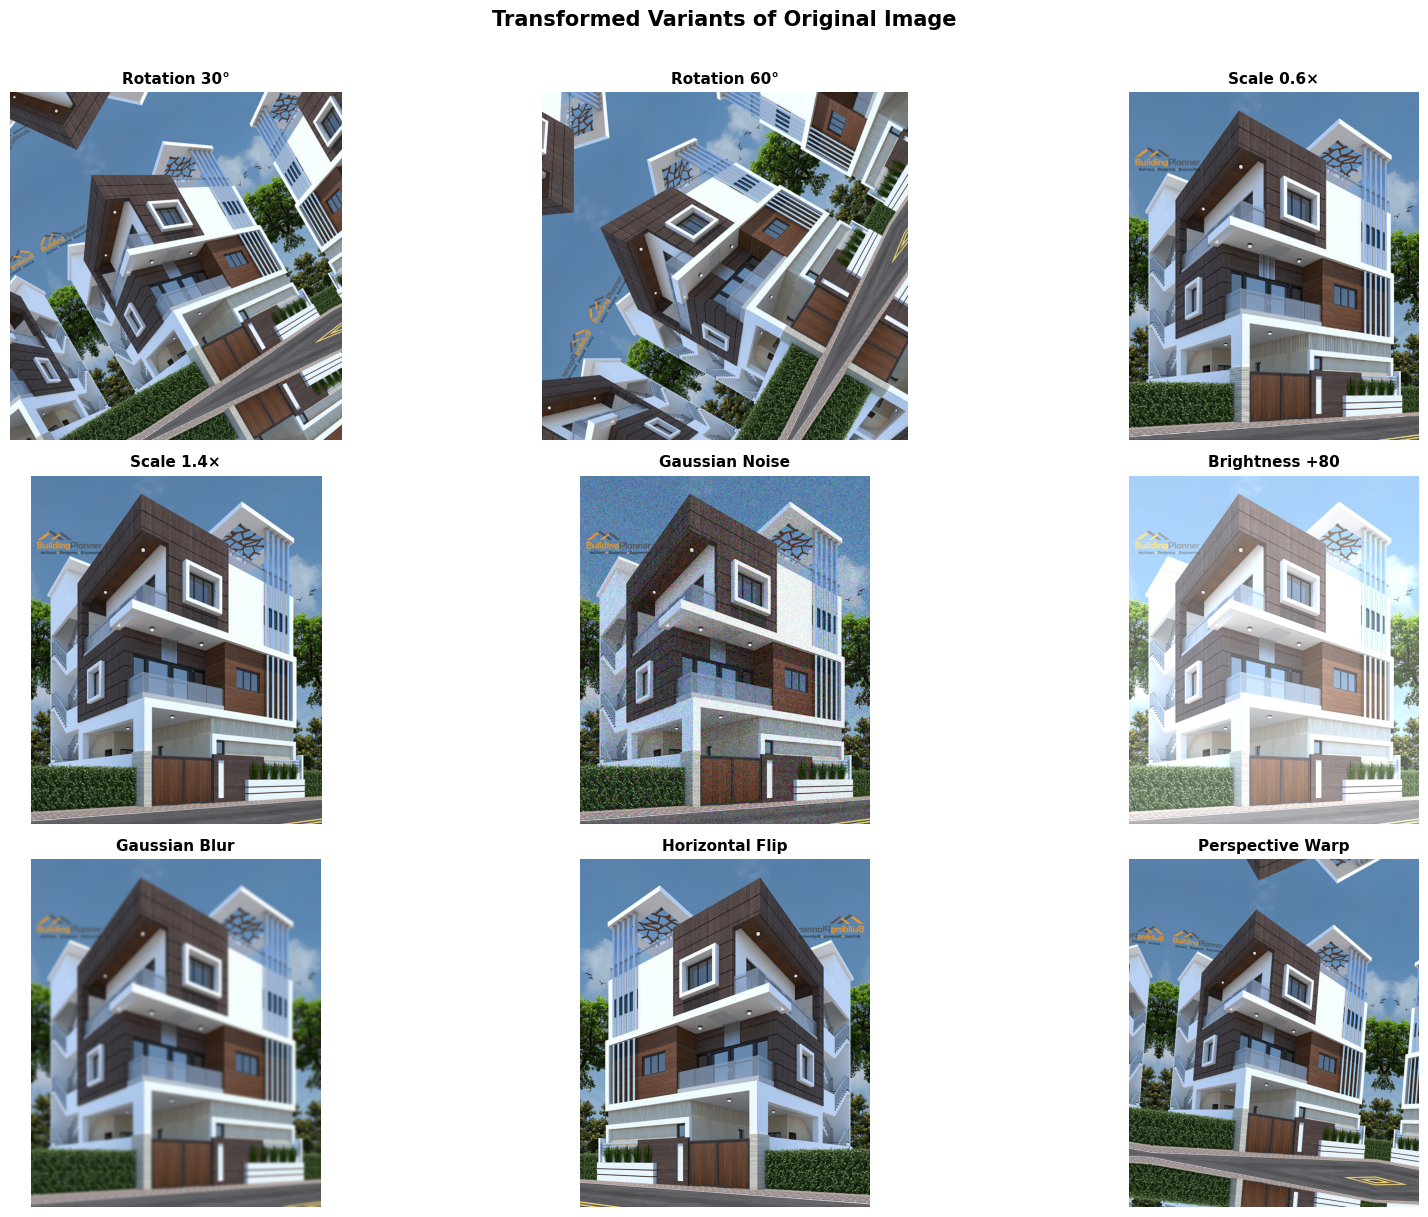

[SAVED] transformed_variants.png


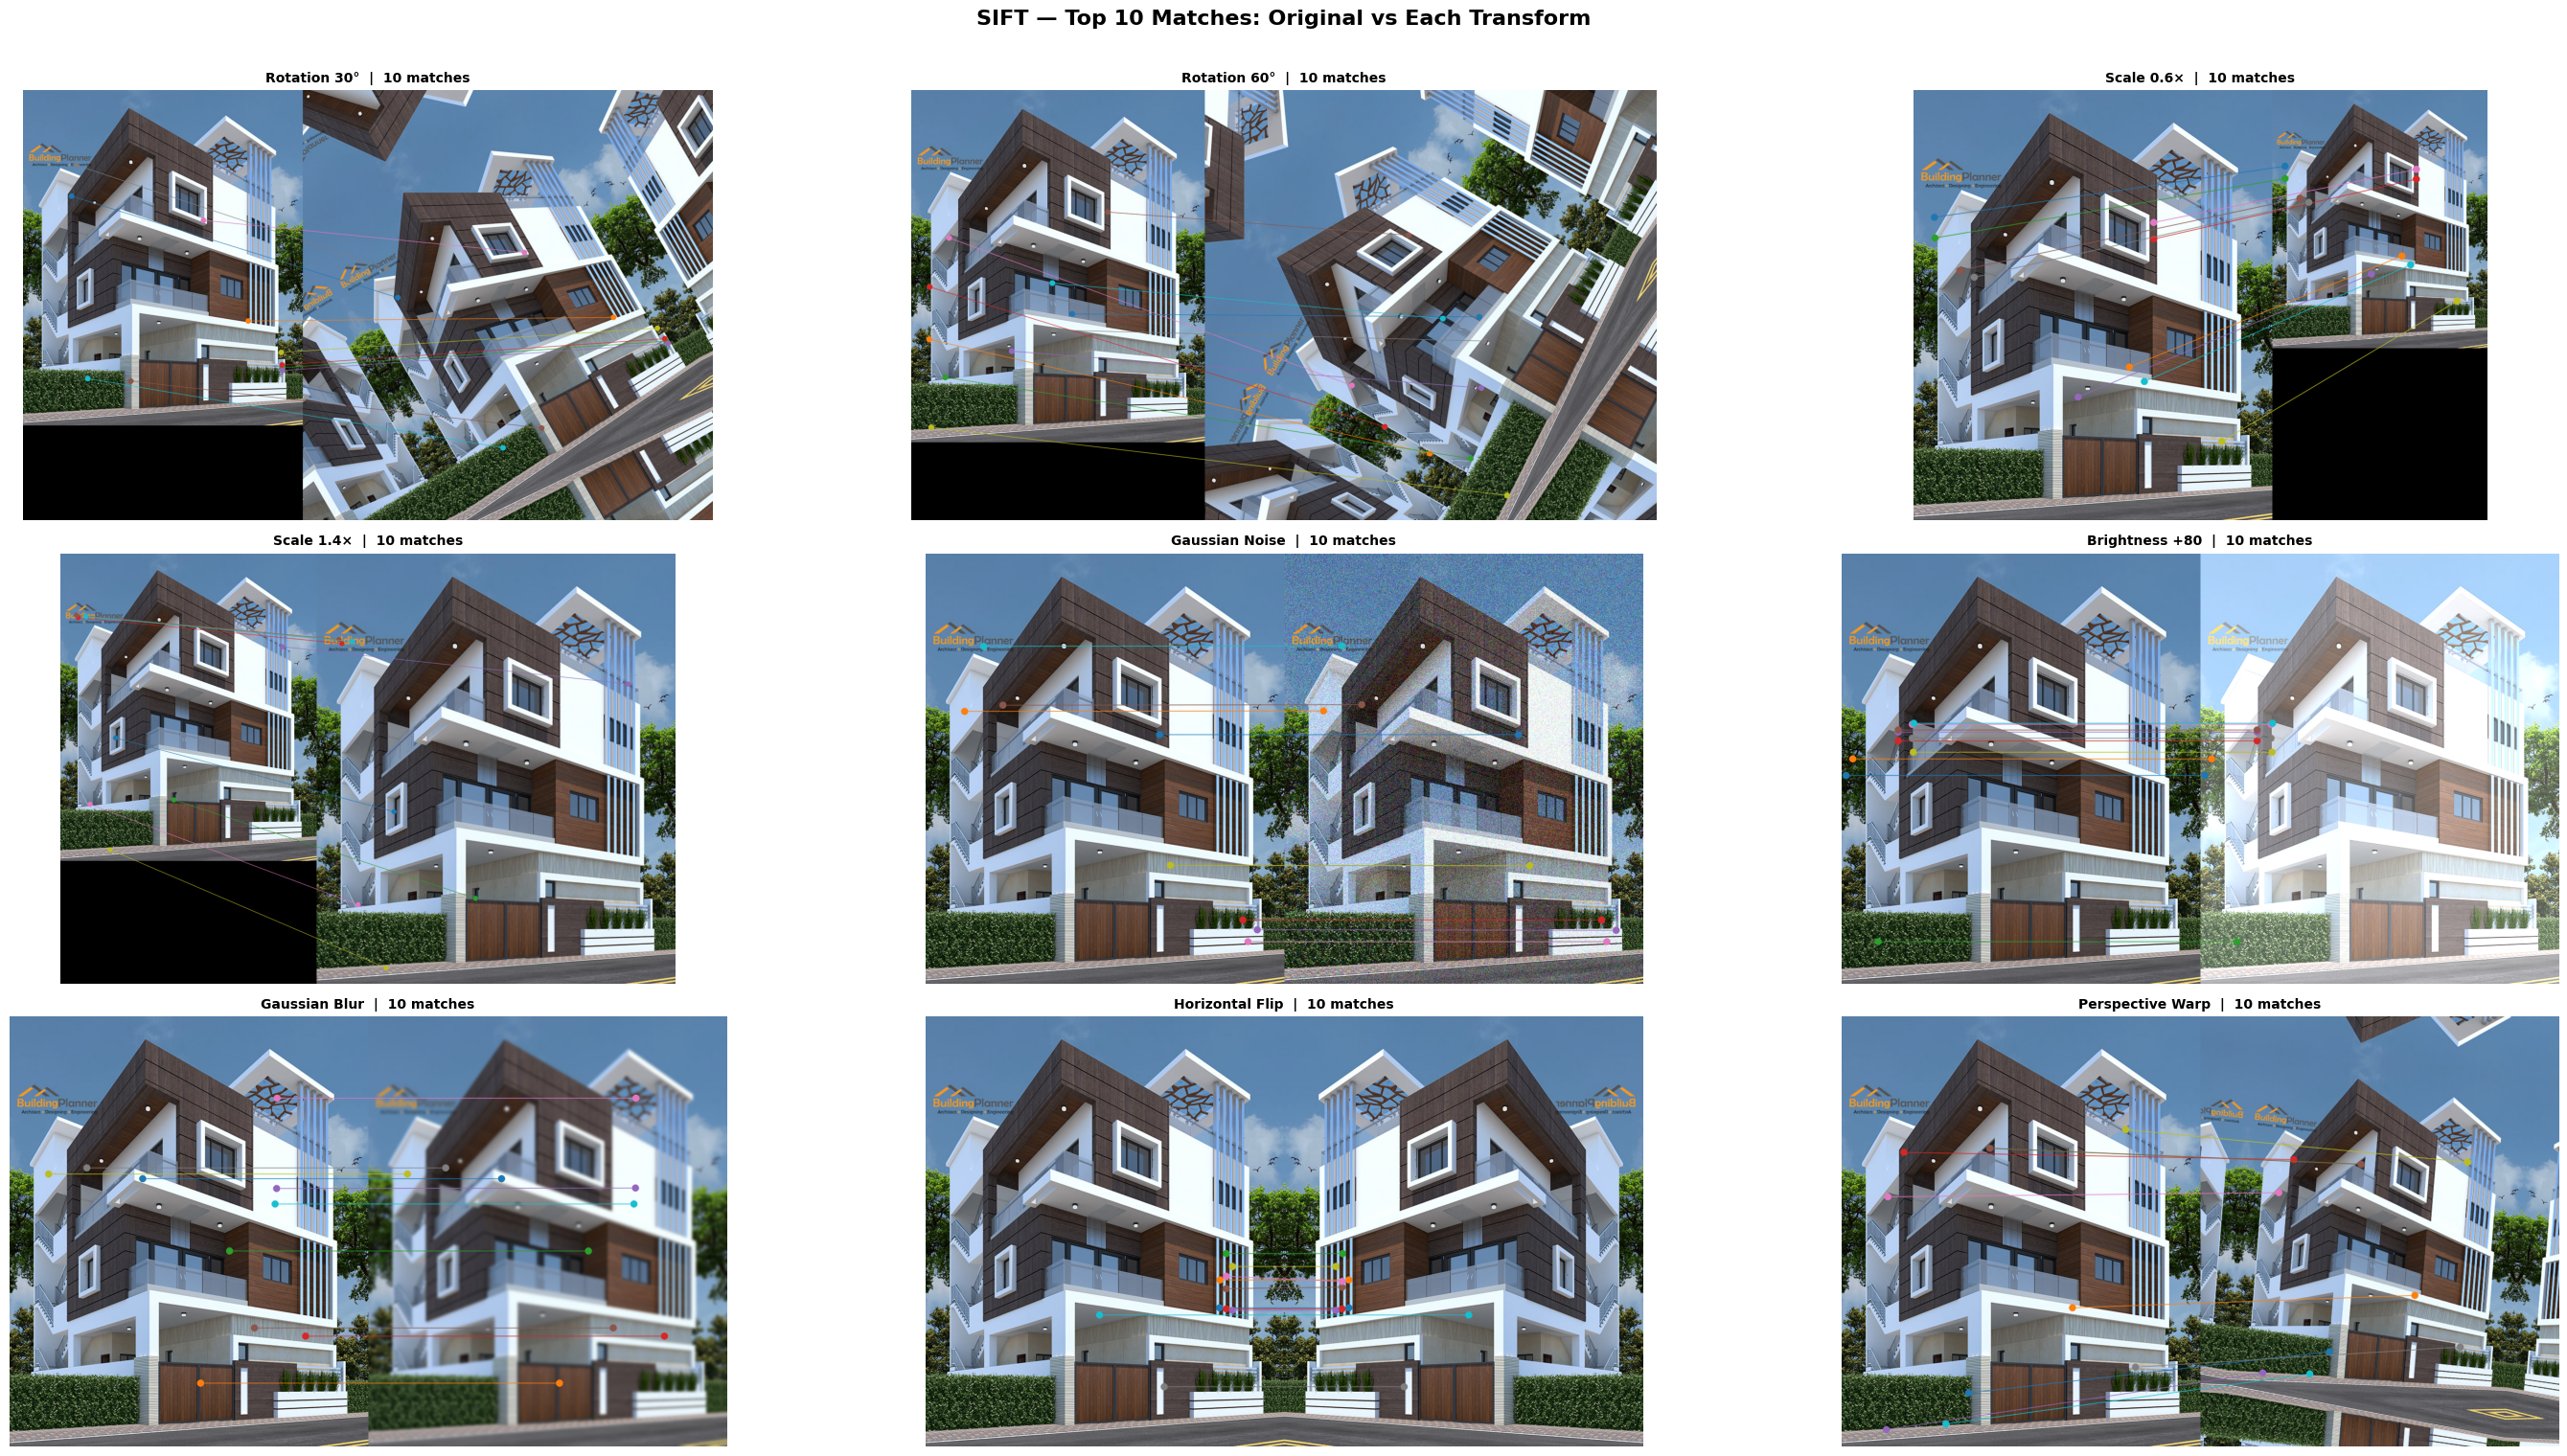

[SAVED] sift_all_matches.png


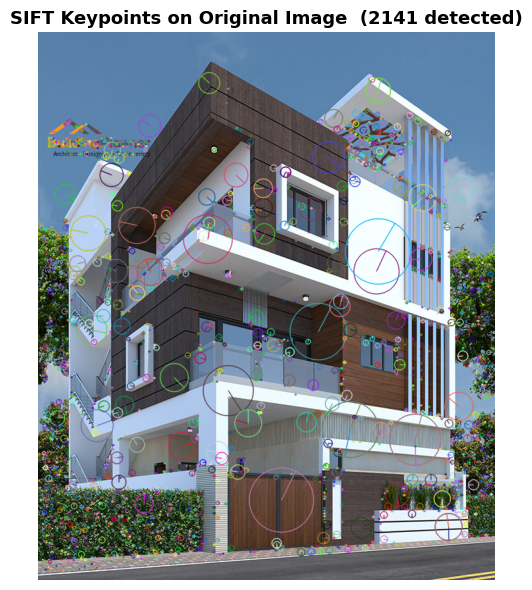

[SAVED] sift_keypoints_original.png


/tmp/ipykernel_2626/826580228.py:115: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(names, rotation=25, ha="right", fontsize=10)


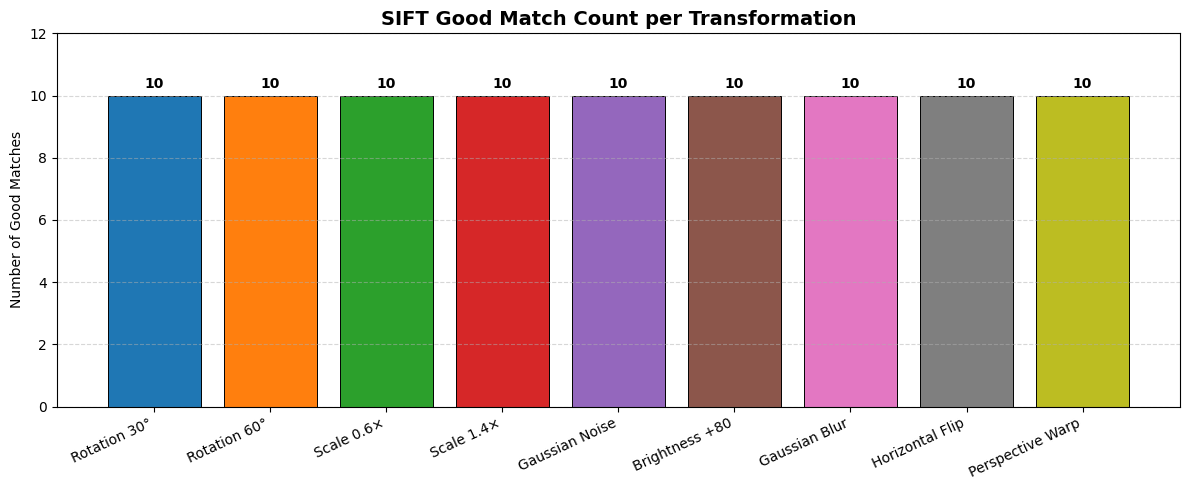

[SAVED] sift_match_counts.png

[DONE] All outputs saved.


{'Rotation 30°': {'transformed': array([[[ 17,  26,  40],
          [ 16,  25,  39],
          [ 15,  25,  40],
          ...,
          [ 70,  68,  80],
          [ 64,  64,  76],
          [ 66,  68,  79]],
  
         [[ 17,  26,  40],
          [ 16,  25,  39],
          [ 16,  25,  39],
          ...,
          [ 69,  70,  80],
          [ 63,  64,  74],
          [ 64,  66,  76]],
  
         [[ 17,  26,  40],
          [ 17,  26,  40],
          [ 18,  27,  41],
          ...,
          [ 67,  72,  81],
          [ 68,  72,  80],
          [ 68,  71,  80]],
  
         ...,
  
         [[ 99, 104, 103],
          [108, 113, 112],
          [ 93,  98,  97],
          ...,
          [ 56,  69, 106],
          [ 52,  68, 100],
          [ 52,  65,  92]],
  
         [[104, 109, 108],
          [103, 108, 107],
          [103, 108, 107],
          ...,
          [ 55,  68, 101],
          [ 55,  66,  92],
          [ 61,  70,  97]],
  
         [[112, 117, 116],
          [ 94,  99,

In [16]:
run_pipeline()